# Pipeline unificado de Canastas Básicas Alimentarias

Este notebook primero unifica las CBA y después carga la composición nutricional del INCAP. Las clases y reglas viven en `src/canasta_inteligente`; aquí solo se orquesta e inspecciona el proceso.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from canasta_inteligente.application.cba_pipeline import (
    build_cba_catalog,
    enrich_catalog_with_incap,
)

## 1. Unificar las CBA

In [2]:
catalog = build_cba_catalog(PROJECT_ROOT / 'data' / 'raw' / 'ine' / 'cba_historicos')
len(catalog)

102

In [3]:
catalog.items

[Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'ARROZ', 'Arroz'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000001F7E3F1D7F0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'Avena de toda clase', 'AVENA DE TODA CLASE'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000001F7BF9E4E10>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='pan_frances', name='PAN FRANCÉS', category='CEREALES', aliases={'PAN FRANCÉS', 'Pan francés'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000001F7BF9E5090>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000001F8248F18B0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x000001F824ABB650>}, nutrition=None, nutrition

In [4]:
summary = {
    region: sum(len(food.price_timelines.get(region, ())) for food in catalog)
    for region in ('general', 'rural', 'urbana')
}
summary['general_derivados'] = sum(
    point.derived
    for food in catalog
    for point in food.price_timelines.get('general', ())
)
summary

{'general': 3978, 'rural': 1680, 'urbana': 1848, 'general_derivados': 1428}

Los puntos generales de 2017–2023 son observaciones originales. Desde 2024 se crea un punto general derivado solo si el alimento tiene observaciones rural y urbana para el mismo año y mes.

In [5]:
food = next(food for food in catalog if len(food.price_timelines.get('general', ())) > 75)
food.name, {region: len(timeline) for region, timeline in food.price_timelines.items()}

('PAN FRANCÉS', {'general': 103, 'rural': 28, 'urbana': 28})

In [6]:
from canasta_inteligente.domain.food import Food

catalog_iterable = iter(catalog.items)

# Revision manual de alimentos 

In [7]:
catalog_iterable = iter(catalog)

In [8]:
food = next(catalog_iterable)
print(food.id)

arroz


In [9]:
food.years_by_region()


{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023],
 'rural': [],
 'urbana': []}

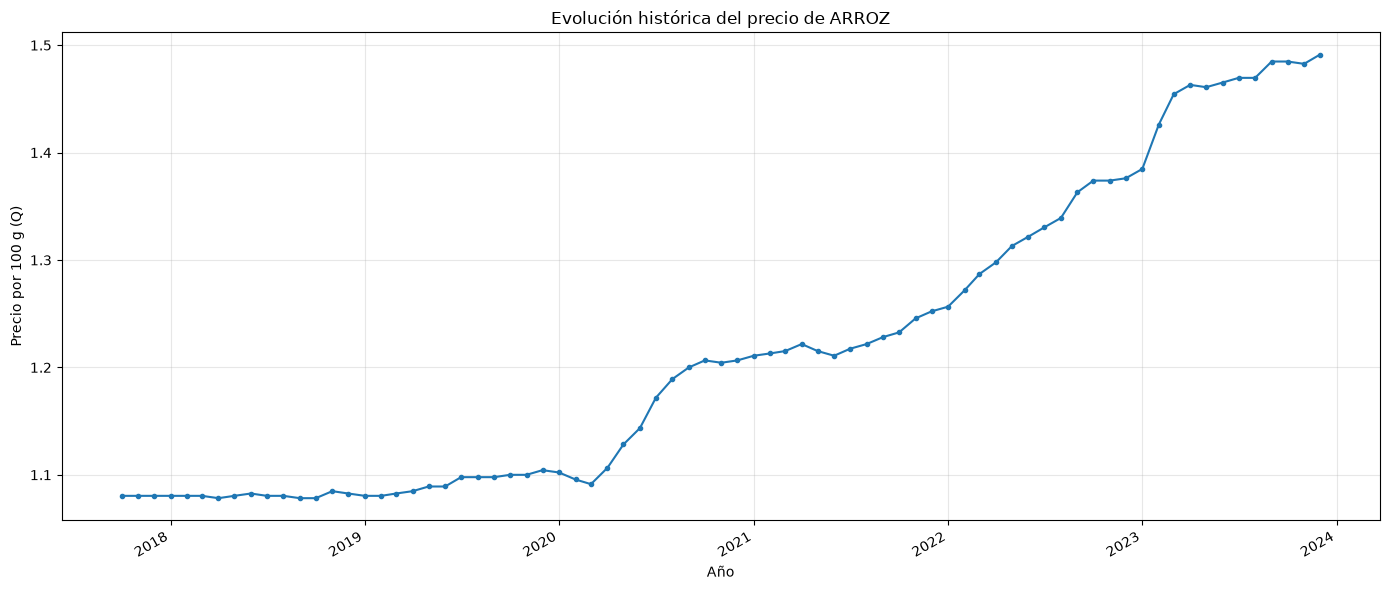

In [10]:
fig, ax = food.plot_timeline('general')

In [11]:
food.name

'ARROZ'

In [12]:
food_timeline_summary = food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de ARROZ — región general
Primer precio registrado: Q1.08 por 100 g (10/2017)
Último precio registrado: Q1.49 por 100 g (12/2023)
Precio más bajo: Q1.08 por 100 g (04/2018)
Precio más alto: Q1.49 por 100 g (12/2023)


Tendencia general de aumento 

In [12]:
for food in catalog:
    if food.id.startswith('arroz'):
        print(food)

Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160AF71D7F0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F0101490>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F0126030>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F015BCB0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F010FF50>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F00B

In [13]:
for food in catalog:
    if food.id.startswith('arroz'):
        print(food)
        print("===============")
        for region, ptf in food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())


Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160AF71D7F0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: general
34.58001397624034
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F0101490>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F0126030>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000160F015BCB0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: rural
17.044065862103597
Region: urbana
18.53221808122289
Region: general
17.78814197166326
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural': <canasta_inteligente.domain.p

Por el numero de gramos consumidos en promedio el arroz corriente corresponde al arroz de la CBA 2017-2023

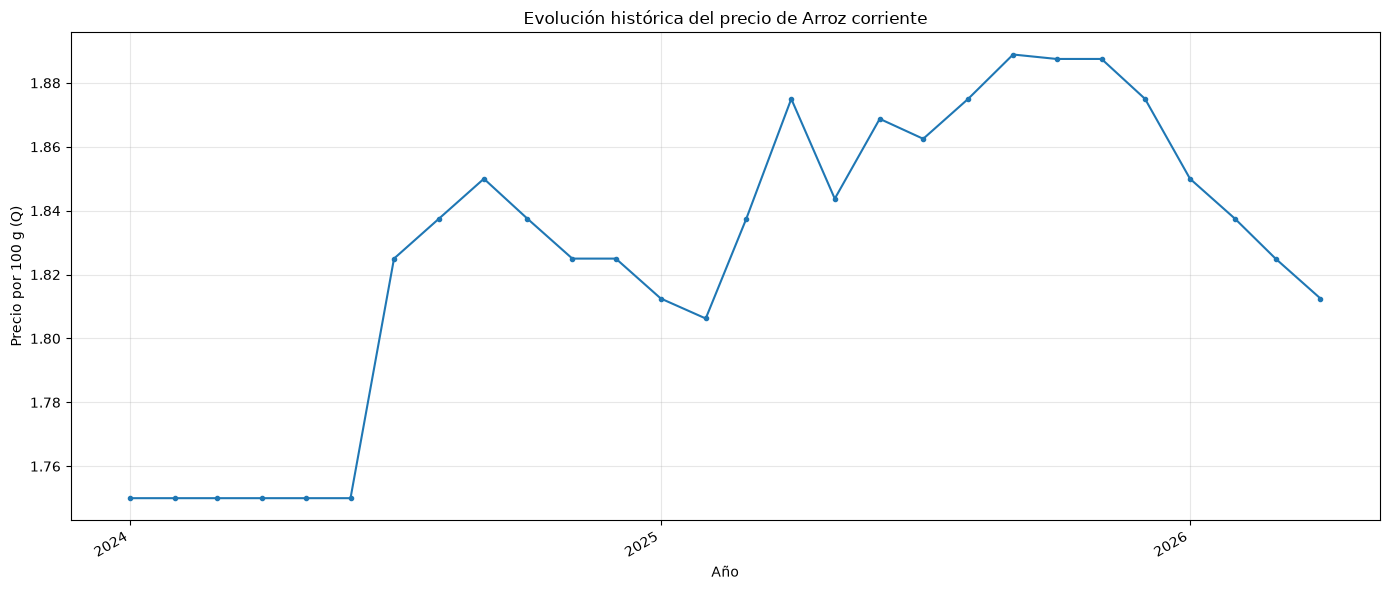

In [14]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('rural')

In [15]:
target_food = catalog.get('arroz_corriente')
food_timeline_summary = target_food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {target_food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de Arroz corriente — región general
Primer precio registrado: Q1.75 por 100 g (01/2024)
Último precio registrado: Q1.81 por 100 g (04/2026)
Precio más bajo: Q1.75 por 100 g (02/2024)
Precio más alto: Q1.89 por 100 g (09/2025)


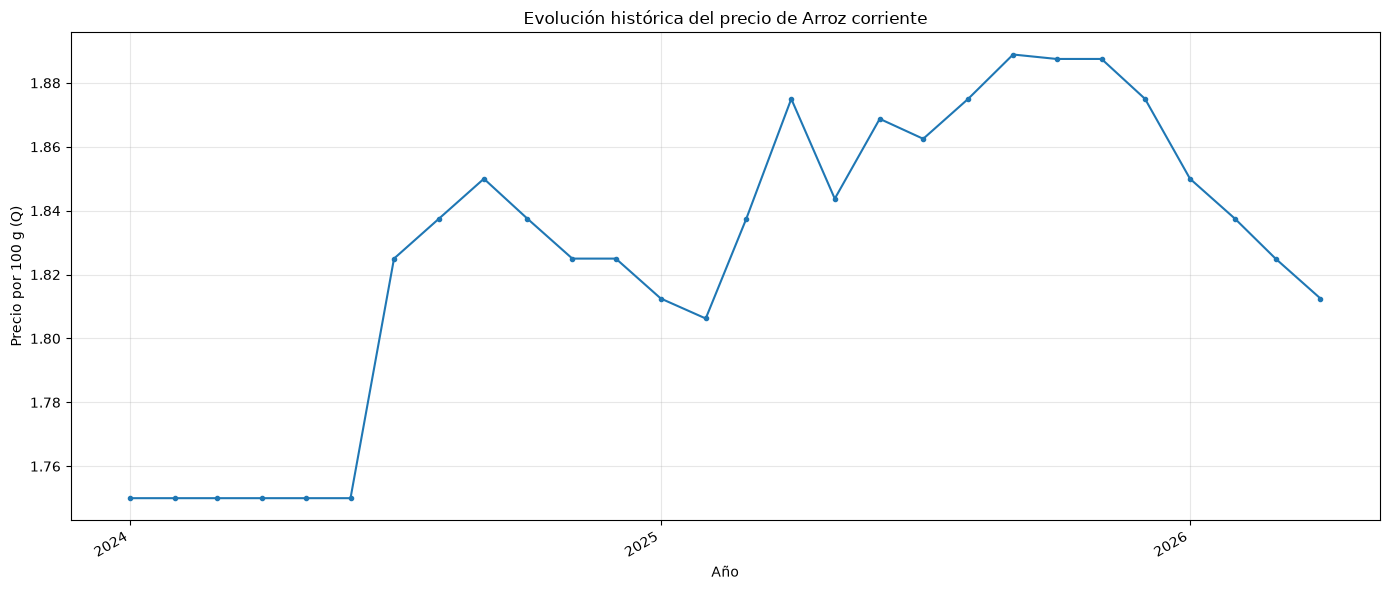

In [15]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('urbana')

In [ ]:
foo

NameError: name 'foo' is not defined

Tendencia general: Aumenta en primera sección. Disminuye por el final. Tramo a tramo muy cambiante siempre dentro del rango de precios de Q1.75 a Q1.88

Dado que, en primer lugar el nombre "arroz corriente" sugiere ser lo mismo que "arroz"; en segunda lugar, el precio de diciembre 2023 y enero 2024

El nombre corriente y los precios en la ultima fecha de Arroz (CBA 2017-2023) y Arroz Corriente (2024-2026) se refieran al mismo alimento. El arroz corriente contra precocido, por su parte, no tiene tanta presencia en la dieta (17.78g a 3.12g en promedio ) de manera que el precocido queda como un alimento independiente.  

In [ ]:
#catalog.merge_foods('arroz', 'arroz_corriente')
# mergeado hasta el final para no afectar el iterable

In [ ]:
food = next(catalog_iterable)
print(food.id)

avena_de_toda_clase


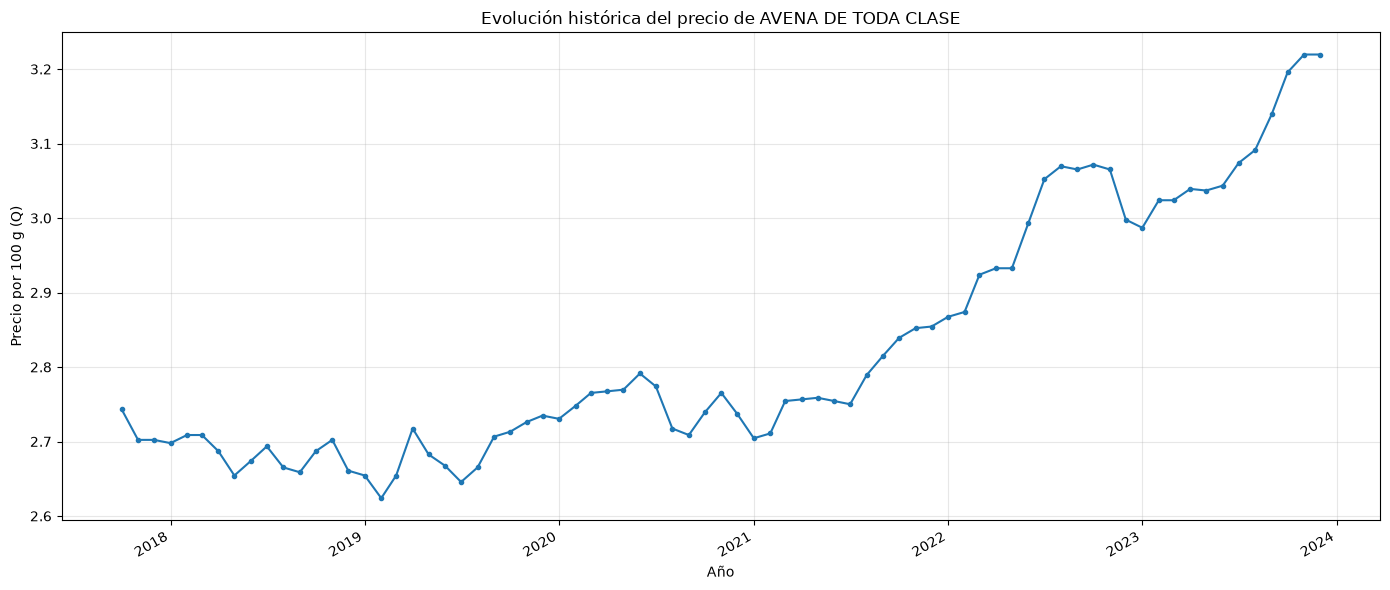

In [ ]:
fig, ax = food.plot_timeline()

In [ ]:
for food in catalog:
    if food.id.startswith('avena'):
        print(food)
        print("===============")
        for region, ptf in food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())

Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'AVENA DE TODA CLASE', 'Avena de toda clase'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000234F844AFD0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: general
10.479385045422797
Food(id='avena_mosh', name='Avena/mosh', category=None, aliases={'Avena/mosh'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x00000234F8A05EB0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: rural
2.4828176204512586


(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Evolución histórica del precio de Avena/mosh'}, xlabel='Año', ylabel='Precio por 100 g (Q)'>)

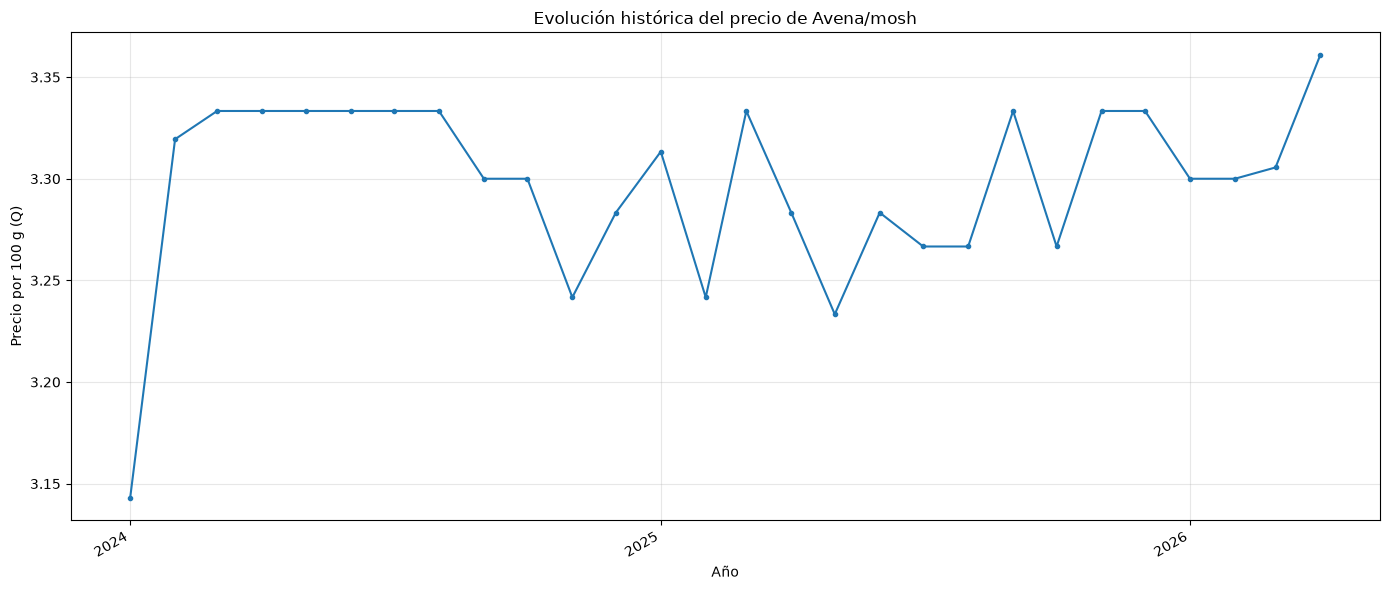

In [ ]:
catalog.get('avena_mosh').plot_timeline()

In [ ]:
#catalog.merge_foods('arroz', 'arroz_corriente')
#catalog.merge_foods('avena_de_toda_clase', 'avena_mosh')

# 3. Merge con INCAP

In [ ]:
incap_report = enrich_catalog_with_incap(
    catalog,
    PROJECT_ROOT / 'data' / 'raw' / 'incap' / 'tabladecomposiciondealimentos.pdf',
)
incap_report

In [ ]:
matched_foods = [food for food in catalog if food.nutrition is not None]
[(food.name, food.nutrition.incap_name, food.nutrition_match_score) for food in matched_foods[:10]]